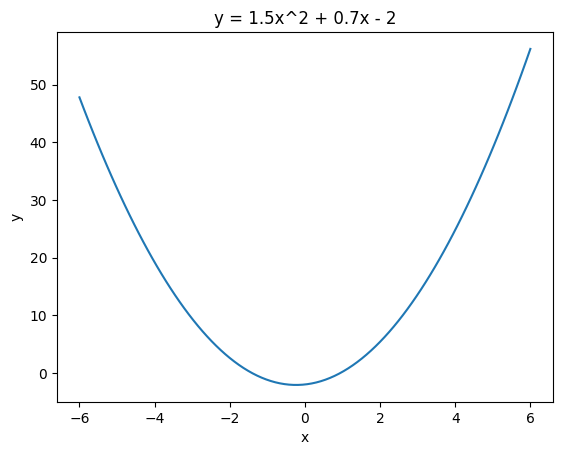

In [13]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)  # For reproducibility

# Set y = 1.5x^2 + 0.7x - 2
def f(x):
    return 1.5 * x**2 + 0.7 * x - 2

# Generate 100 uniformly spaced x values from -6 to 6
x = np.linspace(-6, 6, 100)

# Calculate corresponding y values using the function f
y = f(x)

# Plot the function
plt.plot(x, y)
plt.title('y = 1.5x^2 + 0.7x - 2')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

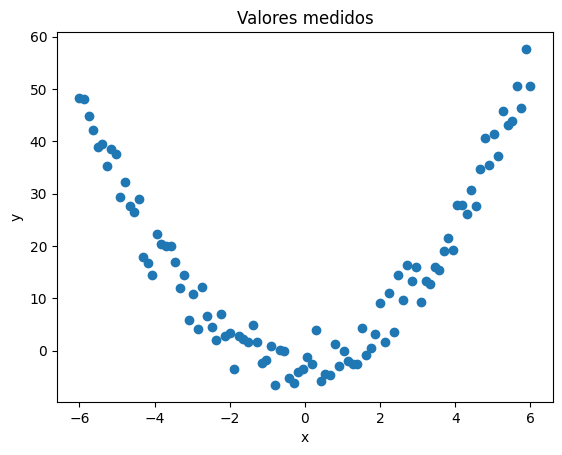

In [14]:
# Add noise to the y values
noise_amp = 0.1 * np.max(np.abs(y))
noise = np.random.uniform(-noise_amp, noise_amp, size=y.shape)
y_measured = y + noise

# Plot the noisy measurements
plt.scatter(x, y_measured)
plt.title('Valores medidos')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

A equação de regressão é $y = \theta_2x^2 + \theta_1x + \theta_0$.

A matriz de regressores é

$A =$
\begin{bmatrix}
x_1^2 & x_1 & 1 \\
x_2^2 & x_2 & 1 \\
\vdots & \vdots & \vdots \\
x_N^2 & x_N & 1
\end{bmatrix}

In [15]:
# Construct the design matrix for quadratic fitting
A = np.vstack([x**2, x, np.ones(len(x))]).T

# Perform least squares fitting to find coefficients
theta, _, _, _ = np.linalg.lstsq(A, y_measured)

# Display the fitted coefficients
print('Coeficientes estimados:')
for i in range(len(theta)):
    print(f'θ_{i} = {theta[i]:.2f}')

Coeficientes estimados:
θ_0 = 1.52
θ_1 = 0.47
θ_2 = -2.59


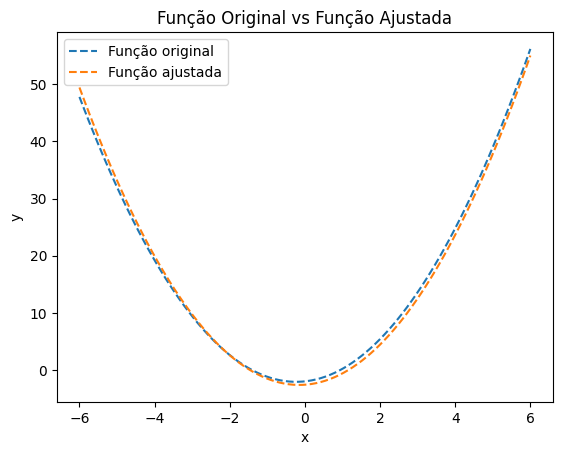

In [16]:
# Define the fitted function
def f_fit(x, theta=theta):
    return theta[0] * x**2 + theta[1] * x + theta[2]

y_fit = f_fit(x, theta)

# Plot the original function and the fitted function
plt.plot(x, y, label='Função original', linestyle='--')
plt.plot(x, y_fit, label='Função ajustada', linestyle='--')
plt.title('Função Original vs Função Ajustada')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [17]:
# Compute and display maximum, average and standard deviation of the error
error = y - y_fit
print(f'Erro máximo: {np.max(np.abs(error)):.2f}')
print(f'Erro médio: {np.mean(np.abs(error)):.2f}')
print(f'Desvio padrão do erro: {np.std(error):.2f}')

Erro máximo: 1.65
Erro médio: 0.82
Desvio padrão do erro: 0.86


In [18]:
# Repeat for N = 1000
x = np.linspace(-6, 6, 1000)
y = f(x)
noise_amp = 0.1 * np.max(np.abs(y))
noise = np.random.uniform(-noise_amp, noise_amp, size=y.shape)
y_measured = y + noise
A = np.vstack([x**2, x, np.ones(len(x))]).T
theta, _, _, _ = np.linalg.lstsq(A, y_measured)
print('Coeficientes estimados para N=1000:')
for i in range(len(theta)):
    print(f'θ_{i} = {theta[i]:.2f}')

Coeficientes estimados para N=1000:
θ_0 = 1.51
θ_1 = 0.68
θ_2 = -2.12


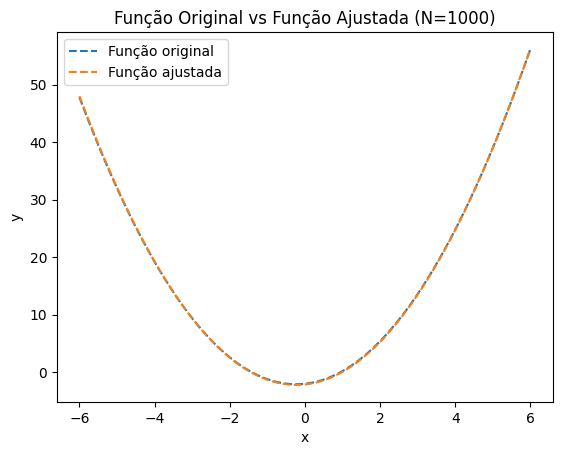

Erro máximo (N=1000): 0.23
Erro médio (N=1000): 0.09
Desvio padrão do erro (N=1000): 0.10


In [19]:
# Compute the fitted values
y_fit = f_fit(x, theta)

# Plot the original function and the fitted function for N=1000
plt.plot(x, y, label='Função original', linestyle='--')
plt.plot(x, y_fit, label='Função ajustada', linestyle='--')
plt.title('Função Original vs Função Ajustada (N=1000)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# Compute and display maximum, average and standard deviation of the error
error = y - y_fit
print(f'Erro máximo (N=1000): {np.max(np.abs(error)):.2f}')
print(f'Erro médio (N=1000): {np.mean(np.abs(error)):.2f}')
print(f'Desvio padrão do erro (N=1000): {np.std(error):.2f}')

Coeficientes estimados com ruído em x (N=1000):
θ_0 = 1.25
θ_1 = 0.66
θ_2 = 0.58


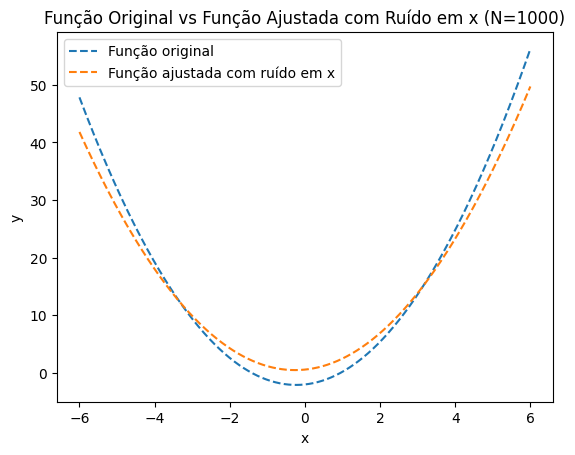

Erro máximo com ruído em x (N=1000): 6.51
Erro médio com ruído em x (N=1000): 2.23
Desvio padrão do erro com ruído em x (N=1000): 2.64


In [20]:
# Now, add noise to the regression variables
noisex_amp = 0.1 * (np.max(x) - np.min(x))
noisex = np.random.uniform(-noisex_amp, noisex_amp, size=x.shape)
x_measured = x + noisex

# Construct the design matrix for quadratic fitting with noisy x
A_noisy = np.vstack([x_measured**2, x_measured, np.ones(len(x_measured))]).T

# Perform least squares fitting to find coefficients with noisy x
theta, _, _, _ = np.linalg.lstsq(A_noisy, y)

# Display the fitted coefficients
print('Coeficientes estimados com ruído em x (N=1000):')
for i in range(len(theta)):
    print(f'θ_{i} = {theta[i]:.2f}')

# Evaluate the fitted function
y_fit = f_fit(x, theta)

# Plot the original function and the fitted function
plt.plot(x, y, label='Função original', linestyle='--')
plt.plot(x, y_fit, label='Função ajustada com ruído em x', linestyle='--')
plt.title('Função Original vs Função Ajustada com Ruído em x (N=1000)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# Compute and display maximum, average and standard deviation of the error
error = y - y_fit
print(f'Erro máximo com ruído em x (N=1000): {np.max(np.abs(error)):.2f}')
print(f'Erro médio com ruído em x (N=1000): {np.mean(np.abs(error)):.2f}')
print(f'Desvio padrão do erro com ruído em x (N=1000): {np.std(error):.2f}')

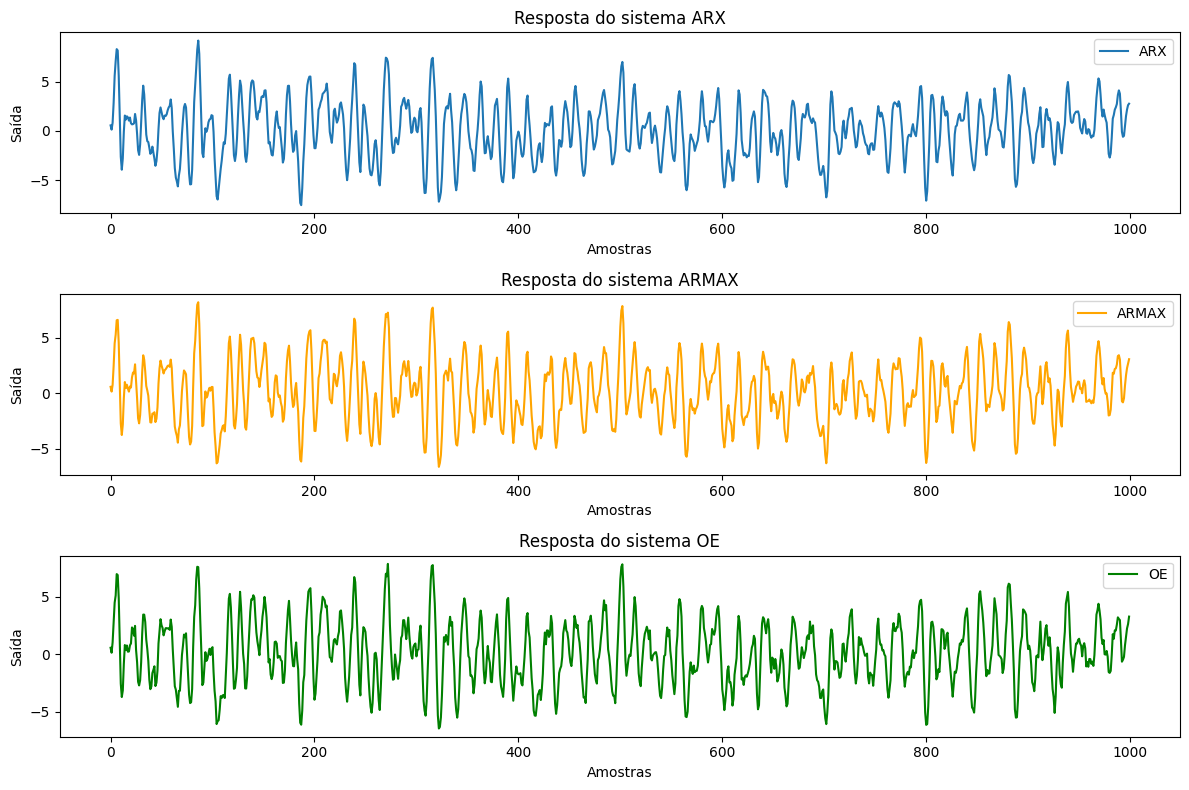

In [21]:
# A(q) = 1 - 1.5q^-1 + 0.7q^-2
# B(q) = 0 + 1.0q^-1 + 0.5q^-2
# C(q) = 1 + 0.8q^-1 + 0.0q^-2

# arx Ay = Bu + e: y[k] - 1.5y[k-1] + 0.7y[k-2] = 1.0u[k-1] + 0.5u[k-2] + e[k]
#                  y[k] = 1.5y[k-1] - 0.7y[k-2] + 1.0u[k-1] + 0.5u[k-2] + e[k]

def arx(y, u, e, k):
    if k < 2:
        return e[k]  # Not enough data for y[k-1], y[k-2], u[k-1], u[k-2]
    return 1.5 * y[k-1] - 0.7 * y[k-2] + 1.0 * u[k-1] + 0.5 * u[k-2] + e[k]

# armax Ay = Bu + Ce: y[k] - 1.5y[k-1] + 0.7y[k-2] = 1.0u[k-1] + 0.5u[k-2] + e[k] - 0.8e[k-1]
#                     y[k] = 1.5y[k-1] - 0.7y[k-2] + 1.0u[k-1] + 0.5u[k-2] + e[k] - 0.8e[k-1]

def armax(y, u, e, k):
    if k < 2:
        return e[k]  # Not enough data for y[k-1], y[k-2], u[k-1], u[k-2], e[k-1]
    return 1.5 * y[k-1] - 0.7 * y[k-2] + 1.0 * u[k-1] + 0.5 * u[k-2] + e[k] - 0.8 * e[k-1]

# F(q) = A(q)

# oe Fy = Bu + Fe: y[k] - 1.5y[k-1] + 0.7y[k-2] = 1.0u[k-1] + 0.5u[k-2] + e[k] - 1.5e[k-1] + 0.7e[k-2]
#                  y[k] = 1.5y[k-1] - 0.7y[k-2] + 1.0u[k-1] + 0.5u[k-2] + e[k] - 1.5e[k-1] + 0.7e[k-2]

def oe(y, u, e, k):
    if k < 2:
        return e[k]  # Not enough data for y[k-1], y[k-2], u[k-1], u[k-2], e[k-1], e[k-2]
    return (1.5 * y[k-1] - 0.7 * y[k-2] + 1.0 * u[k-1] + 0.5 * u[k-2] +
            e[k] - 1.5 * e[k-1] + 0.7 * e[k-2])

# Set random seed for reproducibility
np.random.seed(0)
N_fit = 1000

# nu = white gaussian with zero mean and variance 0.1
nu = np.random.normal(0, np.sqrt(0.1), N_fit)

# u = white uniform in [-1, 1]
u = np.random.uniform(-1, 1, N_fit)

# Set initial conditions
y_arx, y_armax, y_oe = np.zeros(N_fit), np.zeros(N_fit), np.zeros(N_fit)

# Simulate the systems
for k in range(N_fit):
    y_arx[k] = arx(y_arx, u, nu, k)
    y_armax[k] = armax(y_armax, u, nu, k)
    y_oe[k] = oe(y_oe, u, nu, k)

# Plot the results
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(y_arx, label='ARX')
plt.title('Resposta do sistema ARX')
plt.xlabel('Amostras')
plt.ylabel('Saída')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(y_armax, label='ARMAX', color='orange')
plt.title('Resposta do sistema ARMAX')
plt.xlabel('Amostras')
plt.ylabel('Saída')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(y_oe, label='OE', color='green')
plt.title('Resposta do sistema OE')
plt.xlabel('Amostras')
plt.ylabel('Saída')
plt.legend()

plt.tight_layout()
plt.show()

# Estimação de ARX

Dado

\begin{equation*}
A(z)y[k] = B(z)u[k] + e[k]
\end{equation*}

com dois atrasos em $A(z)$ e $B(z)$,

\begin{align*}
y[k] + a_1y[k-1] + a_2y[k-2] &= b_1u[k-1] + b_2u[k-2] + e[k] \\
y[k] &= -a_1y[k-1] - a_2y[k-2] + b_1u[k-1] + b_2u[k-2] + e[k]
\end{align*}

Seja

\begin{align*}
Y &=
\begin{bmatrix}
y[2] \\
y[3] \\
y[4] \\
\vdots \\
y[N-1]
\end{bmatrix} \\
\Phi &=
\begin{bmatrix}
y[1] & y[0] & u[1] & u[0] \\
y[2] & y[1] & u[2] & u[1] \\
y[3] & y[2] & u[3] & u[2] \\
\vdots & \vdots & \vdots & \vdots \\
y[N-2] & y[N-3] & u[N-2] & u[N-3]
\end{bmatrix} \\
\theta &=
\begin{bmatrix}
-a_1 \\
-a_2 \\
b_1 \\
b_2
\end{bmatrix} \\
E &=
\begin{bmatrix}
e[2] \\
e[3] \\
e[4] \\
\vdots \\
e[N-1]
\end{bmatrix}
\end{align*},

então

\begin{equation*}
Y = \Phi\theta + E
\end{equation*}

e a estimativa por mínimos quadrados é

\begin{equation*}
\hat{\theta} = (\Phi^T\Phi)^{-1}\Phi^TY
\end{equation*}

Coeficientes estimados: A = [ 1.         -1.49415333  0.69915224], B = [0.         0.96999492 0.49875072]


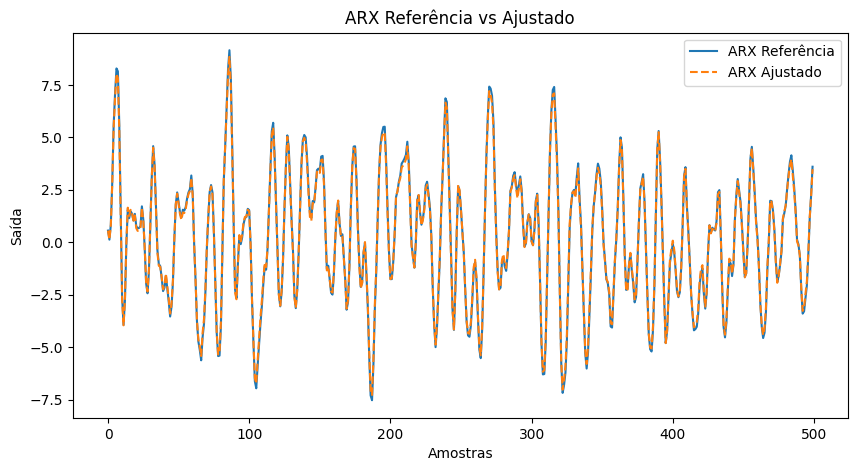

In [22]:
def fit_arx(y: np.ndarray, u: np.ndarray, na: int, nb: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Estimate ARX model parameters using least squares.

    Parameters:
    y : np.ndarray
        Output data.
    u : np.ndarray
        Input data.
    na : int
        Number of poles (order of A).
    nb : int
        Number of zeros (order of B).

    Returns:
    A : np.ndarray
        Estimated coefficients of A polynomial.
    B : np.ndarray
        Estimated coefficients of B polynomial.
    """
    N = len(y)
    assert len(u) == N, "Input and output data must have the same length."

    # Ensure 0 mean for input and output
    u = u - np.mean(u)
    y = y - np.mean(y)

    # Construct the regression matrix
    phi = np.zeros((N - max(na, nb), na + nb))
    for k in range(max(na, nb), N):
        # Fill in the A part (output past values)
        for i in range(1, na + 1):
            phi[k - max(na, nb), i - 1] = -y[k - i]
        # Fill in the B part (input past values)
        for j in range(1, nb + 1):
            phi[k - max(na, nb), na + j - 1] = u[k - j]

    # Corresponding output vector
    y_reg = y[max(na, nb):]

    # Solve the least squares problem
    theta, _, _, _ = np.linalg.lstsq(phi, y_reg, rcond=None)

    # Separate A and B coefficients
    A = np.concatenate(([1], theta[:na]))  # A[0] = 1
    B = np.concatenate(([0], theta[na:]))  # B[0] = 0

    return A, B

arx_A, arx_B = fit_arx(y_arx, u, na=2, nb=2)
print(f'Coeficientes estimados: A = {arx_A}, B = {arx_B}')

def arx_fitted(y, u, e, k, A, B):
    if k < 2:
        return e[k]  # Not enough data for y[k-1], y[k-2], u[k-1], u[k-2]
    return -A[1] * y[k-1] - A[2] * y[k-2] + B[0] * u[k] + B[1] * u[k-1] + B[2] * u[k-2] + e[k]

N_val = 500

y_arx_fit, y_arx_ref = np.zeros(N_val), np.zeros(N_val)

for k in range(N_val):
    y_arx_fit[k] = arx_fitted(y_arx_fit, u, nu, k, arx_A, arx_B)
    y_arx_ref[k] = arx(y_arx_ref, u, nu, k)

plt.figure(figsize=(10, 5))
plt.plot(y_arx_ref, label='ARX Referência')
plt.plot(y_arx_fit, label='ARX Ajustado', linestyle='--')
plt.title('ARX Referência vs Ajustado')
plt.xlabel('Amostras')
plt.ylabel('Saída')
plt.legend()
plt.show()

# Estimação de ARMAX

Dado

\begin{equation*}
A(z)y[k] = B(z)u[k] + C(z)e[k]
\end{equation*}

com dois atrasos em $A(z)$, $B(z)$ e $C(z)$,

\begin{align*}
y[k] + a_1y[k-1] + a_2y[k-2] &= b_1u[k-1] + b_2u[k-2] + e[k] + c_1e[k-1] + c_2e[k-2] \\
y[k] &= -a_1y[k-1] - a_2y[k-2] + b_1u[k-1] + b_2u[k-2] + e[k] + c_1e[k-1] + c_2e[k-2]
\end{align*}

A construção

\begin{equation*}
Y = \Phi\theta
\end{equation*}

com

\begin{align*}
Y &=
\begin{bmatrix}
y[2] \\
y[3] \\
y[4] \\
\vdots \\
y[N-1]
\end{bmatrix} \\
\Phi &=
\begin{bmatrix}
y[1] & y[0] & u[1] & u[0] & e[1] & e[0] \\
y[2] & y[1] & u[2] & u[1] & e[2] & e[1] \\
y[3] & y[2] & u[3] & u[2] & e[3] & e[2] \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
y[N-2] & y[N-3] & u[N-2] & u[N-3] & e[N-2] & e[N-3]
\end{bmatrix} \\
\theta &=
\begin{bmatrix}
-a_1 \\
-a_2 \\
b_1 \\
b_2 \\
c_1 \\
c_2
\end{bmatrix}
\end{align*}

é valida, mas não pode ser usada para estimar $\theta$ por mínimos quadrados, pois $e[k]$ não é conhecido. Neste caso, o método *quadrados mínimos extendido* é uma solução. O algoritmo é:

1. Estime um modelo ARX sobre os dados;
2. Calcule os resíduos do modelo ARX estimado;
3. Use os resíduos como uma estimativa para $e[k]$ e construa a matriz de regressores;
4. Estime o modelo ARMAX usando mínimos quadrados;
5. Calcule os resíduos do modelo ARMAX estimado;
6. Repita os passos 3 a 5 até convergência.

Coeficientes estimados: A = [ 1.         -1.45736616  0.68859799], B = [0.         0.96026416 0.55404632], C = [ 1.         -0.69758384  0.03110467], iterações = 99


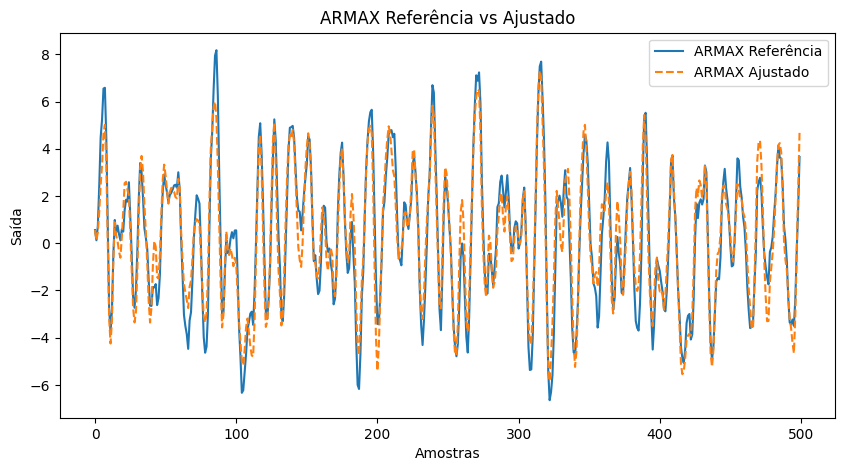

In [23]:
def _simulate_one_step_pred(y: np.ndarray, u: np.ndarray, A: np.ndarray, B: np.ndarray, C: np.ndarray):
    """
    Compute one-step-ahead predictions yhat and innovations ehat for given A,B,C.
    Conventions:
      A = [1, a1, a2, ...]
      B = [0, b1, b2, ...]
      C = [1, c1, c2, ...]
    Returns yhat, ehat (length N). ehat[0:start] will remain zero (not computable).
    """
    N = len(y)
    na = len(A) - 1
    nb = len(B) - 1
    nc = len(C) - 1
    start = max(na, nb, nc)
    yhat = np.zeros(N)
    ehat = np.zeros(N)
    # for k < start, leave ehat as zero
    for k in range(start, N):
        # AR part: -A[i]*y[k-i] summed
        ar_sum = 0.0
        for i in range(1, na + 1):
            ar_sum += -A[i] * y[k - i]
        # Input part: B[0]*u[k] + B[1]*u[k-1] + ...
        bu_sum = 0.0
        for j in range(0, nb + 1):
            bu_sum += B[j] * u[k - j]
        # MA part: C[1]*ehat[k-1] + ...
        ce_sum = 0.0
        for l in range(1, nc + 1):
            ce_sum += C[l] * ehat[k - l]
        yhat[k] = ar_sum + bu_sum + ce_sum
        ehat[k] = y[k] - yhat[k]
    return yhat, ehat

def fit_armax(y: np.ndarray, u: np.ndarray, na: int, nb: int, nc: int,
              tol: float | None = None, max_iter: int | None = None) -> tuple[np.ndarray, np.ndarray, np.ndarray, int]:
    """
    Estimate ARMAX parameters using Extended Least Squares (Iterative GLS / IGLS).
    Returns (A, B, C) where A = [1, a1, ..., a_na], B = [0, b1, ..., b_nb], C = [1, c1, ..., c_nc].

    Parameters
    ----------
    y, u : np.ndarray
        Measured signals (1D arrays, same length).
    na, nb, nc : int
        Orders: na (A order), nb (number of B lags), nc (C order).
    tol : float | None
        Convergence tolerance on parameter vector change. Defaults 0.01 * max(abs(theta)).
    max_iter : int | None
        Maximum number of iterations. Defaults to N // 10.

    Returns
    -------
    A : np.ndarray
        Estimated coefficients of A polynomial.
    B : np.ndarray
        Estimated coefficients of B polynomial.
    C : np.ndarray
        Estimated coefficients of C polynomial.
    iter_count : int
        Number of iterations performed.
    """

    y = np.asarray(y, dtype=float).copy()
    u = np.asarray(u, dtype=float).copy()
    N = len(y)
    assert len(u) == N, "u and y must have same length."

    if max_iter is None:
        max_iter = N // 10

    # Remove means
    u = u - np.mean(u)
    y = y - np.mean(y)

    # quick case: nc == 0 reduces to ARX LS
    if nc == 0:
        A, B = fit_arx(y, u, na, nb)
        C = np.array([1.0])
        return A, B, C, 0

    # Initialization from ARX (c's = 0)
    A, B = fit_arx(y, u, na, nb)
    C = np.concatenate(([1.0], np.zeros(nc)))
    # initial residuals from ARX one-step-ahead
    _, ehat = _simulate_one_step_pred(y, u, A, B, C)

    start = max(na, nb, nc)
    M = N - start
    if M <= 0:
        raise ValueError("Not enough data points for the chosen model orders. Increase N or reduce orders.")

    theta_prev = np.concatenate((A[1:], B[1:], C[1:]))  # current parameters vector without the leading 1/0

    if tol is None:
        tol = float(0.01 * np.max(np.abs(theta_prev)))

    for it in range(max_iter):
        # Build regression matrix using current innovations (ehat)
        phi = np.zeros((M, na + nb + nc))
        for k in range(start, N):
            r = k - start
            # A part: -y[k-1], ..., -y[k-na]
            for i in range(1, na + 1):
                phi[r, i - 1] = -y[k - i]
            # B part: u[k-1], ..., u[k-nb]
            for j in range(1, nb + 1):
                phi[r, na + j - 1] = u[k - j]
            # C part: ehat[k-1], ..., ehat[k-nc]
            for l in range(1, nc + 1):
                phi[r, na + nb + l - 1] = ehat[k - l]

        y_reg = y[start:]
        theta, *_ = np.linalg.lstsq(phi, y_reg, rcond=None)

        # Unpack into A,B,C (with leading 1/0)
        A_new = np.concatenate(([1.0], theta[:na]))
        B_new = np.concatenate(([0.0], theta[na:na + nb]))
        C_new = np.concatenate(([1.0], theta[na + nb:na + nb + nc]))

        # Compute new one-step-ahead residuals using updated parameters
        _, ehat_new = _simulate_one_step_pred(y, u, A_new, B_new, C_new)

        theta_curr = np.concatenate((A_new[1:], B_new[1:], C_new[1:]))
        diff = np.linalg.norm(theta_curr - theta_prev)
        # update for next iteration
        A, B, C = A_new, B_new, C_new
        ehat = ehat_new
        theta_prev = theta_curr

        if diff < tol:
            break

    return A, B, C, it

# Fit ARMAX by ELS
A, B, C, it = fit_armax(y_armax, u, na=2, nb=2, nc=2)

print(f'Coeficientes estimados: A = {A}, B = {B}, C = {C}, iterações = {it}')

def armax_fitted(y, u, e, k, A, B, C):
    if k < 2:
        return e[k]  # Not enough data for y[k-1], y[k-2], u[k-1], u[k-2], e[k-1], e[k-2]
    return -A[1] * y[k-1] - A[2] * y[k-2] + B[0] * u[k] + B[1] * u[k-1] + B[2] * u[k-2] + B[0] * e[k] + C[1] * e[k-1] + C[2] * e[k-2]

y_arx_fit, y_arx_ref = np.zeros(N_val), np.zeros(N_val)

for k in range(N_val):
    y_arx_fit[k] = armax_fitted(y_arx_fit, u, nu, k, A, B, C)
    y_arx_ref[k] = armax(y_arx_ref, u, nu, k)

plt.figure(figsize=(10, 5))
plt.plot(y_arx_ref, label='ARMAX Referência')
plt.plot(y_arx_fit, label='ARMAX Ajustado', linestyle='--')
plt.title('ARMAX Referência vs Ajustado')
plt.xlabel('Amostras')
plt.ylabel('Saída')
plt.legend()
plt.show()

# Estimação de OE

Coeficientes estimados: F = [ 1.         -1.4963714   0.69816568], B = [0.         0.96415241 0.53712363]


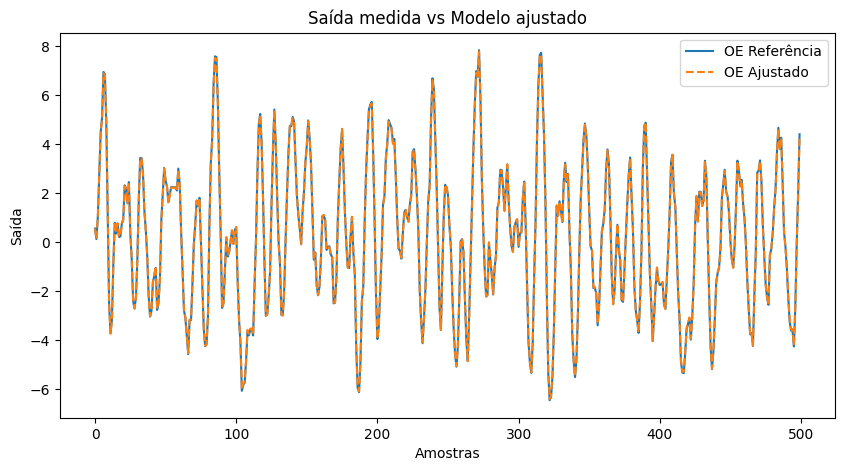

In [24]:
def _filter_with_denominator(a_coef, x):
    na = len(a_coef) - 1
    N = len(x)
    w = np.zeros(N)
    for k in range(N):
        s = 0.0
        for i in range(1, na + 1):
            if k - i >= 0:
                s += -a_coef[i] * w[k - i]
        w[k] = s + x[k]
    return w

def _build_V_for_f(f, u, nb, nk):
    na = len(f)
    a_coef = np.concatenate(([1.0], f))
    N = len(u)
    V = np.zeros((N, nb))
    for j in range(1, nb + 1):
        u_del = np.zeros(N)
        if j < N:
            u_del[j:] = u[:N - j]
        vj = _filter_with_denominator(a_coef, u_del)
        V[:, j - 1] = vj
    return V

def _residuals_given_f(f, y, u, na, nb, nk):
    N = len(y)
    start = max(na, nb + nk - 1)
    V = _build_V_for_f(f, u, nb, nk)
    V_reg = V[start:, :]
    y_reg = y[start:]
    b_hat, *_ = np.linalg.lstsq(V_reg, y_reg, rcond=None)
    yhat = V.dot(b_hat)
    res = y - yhat
    return res[start:], b_hat

def fit_oe(y: np.ndarray, u: np.ndarray, na: int, nb: int, nk: int = 1,
           tol: float | None = None, max_iter: int | None = None):
    if tol is None:
        tol = 1e-8
    if max_iter is None:
        max_iter = 200

    y = np.asarray(y, dtype=float).copy()
    u = np.asarray(u, dtype=float).copy()
    N = len(y)
    assert len(u) == N

    u = u - np.mean(u)
    y = y - np.mean(y)

    # init
    A_init, B_init = fit_arx(y, u, na, nb + nk - 1)
    f0 = A_init[1:]
    if len(f0) < na:
        f0 = np.concatenate((f0, np.zeros(na - len(f0))))
    elif len(f0) > na:
        f0 = f0[:na]
    # ensure float
    f = f0.astype(float)

    # Gauss-Newton with finite differences and LM damping on f only
    lambda_diag = 1e-3
    for it in range(max_iter):
        r, b_hat = _residuals_given_f(f, y, u, na, nb, nk)
        cost = 0.5 * np.dot(r, r)
        # finite difference Jacobian of residuals w.r.t f (numerical)
        eps = 1e-6
        J = np.zeros((len(r), len(f)))
        for j in range(len(f)):
            f_pert = f.copy()
            f_pert[j] += eps
            r_pert, _ = _residuals_given_f(f_pert, y, u, na, nb, nk)
            J[:, j] = (r_pert - r) / eps
        # Gauss-Newton step: solve (J^T J + lambda I) delta = -J^T r
        JTJ = J.T.dot(J)
        JTr = J.T.dot(r)
        H_lm = JTJ + lambda_diag * np.eye(len(f))
        try:
            delta = np.linalg.solve(H_lm, -JTr)
        except np.linalg.LinAlgError:
            delta = np.linalg.lstsq(H_lm, -JTr, rcond=None)[0]
        f_new = f + delta
        r_new, b_new = _residuals_given_f(f_new, y, u, na, nb, nk)
        cost_new = 0.5 * np.dot(r_new, r_new)
        # LM acceptance rule
        if cost_new < cost:
            # accept step, decrease damping
            f = f_new
            b_hat = b_new
            lambda_diag = max(lambda_diag / 10, 1e-12)
        else:
            # reject, increase damping
            lambda_diag = lambda_diag * 10
        # convergence check on parameter change norm
        if np.linalg.norm(delta) < tol:
            break

    F = np.concatenate(([1.0], f))
    B = np.concatenate(([0.0], b_hat))
    return F, B

F_hat, B_hat = fit_oe(y_oe, u, na=2, nb=2, nk=1, tol=1e-9, max_iter=200)

print(f'Coeficientes estimados: F = {F_hat}, B = {B_hat}')

def oe_fitted(y, u, e, k, B, F):
    if k < 2:
        return e[k]  # Not enough data for y[k-1], y[k-2], u[k-1], u[k-2], e[k-1], e[k-2]
    return -F[1] * y[k-1] - F[2] * y[k-2] + B[0] * u[k] + B[1] * u[k-1] + B[2] * u[k-2] + F[0] * e[k] + F[1] * e[k-1] + F[2] * e[k-2]

y_oe_fit, y_oe_ref = np.zeros(N_val), np.zeros(N_val) 

for k in range(N_val):
    y_oe_fit[k] = oe_fitted(y_oe_fit, u, nu, k, B_hat, F_hat)
    y_oe_ref[k] = oe(y_oe_ref, u, nu, k)

plt.figure(figsize=(10, 5))
plt.plot(y_oe_ref, label='OE Referência')
plt.plot(y_oe_fit, '--', label='OE Ajustado')
plt.title('Saída medida vs Modelo ajustado')
plt.xlabel('Amostras')
plt.ylabel('Saída')
plt.legend()
plt.show()